# Cost Aware Framework(Image Detection Model)

In [ ]:
# CIFAKE Image Detection

## Project: A Cost-Aware Framework for Synthetic Data Detection in Data Acquisition Pipelines

### Dataset: CIFAKE

### Objective: Detect Real vs AI-Generated Images

# Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


# Install Dependencies

In [ ]:
!pip install torch torchvision
!pip install matplotlib seaborn
!pip install scikit-learn
!pip install tqdm

# Import Libraries

In [ ]:
import os
import random
import numpy as np

import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import torchvision.transforms as transforms

from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)

# Dataset Paths

In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'SyntheticDataDetection']


In [ ]:
import os

DATASET_ROOT = "/content/drive/MyDrive/SyntheticDataDetection/datasets/CIFAKE"

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
TEST_DIR = os.path.join(DATASET_ROOT, "test")

print("Train Path:", TRAIN_DIR)
print("Test Path:", TEST_DIR)

print("\nTrain Classes:", os.listdir(TRAIN_DIR))
print("Test Classes:", os.listdir(TEST_DIR))

Train Path: /content/drive/MyDrive/SyntheticDataDetection/datasets/CIFAKE/train
Test Path: /content/drive/MyDrive/SyntheticDataDetection/datasets/CIFAKE/test

Train Classes: ['FAKE', 'REAL']
Test Classes: ['FAKE', 'REAL']


# Dataset Statistics

In [ ]:
print(DATASET_ROOT)
print(TRAIN_DIR)

print("\nDATASET ROOT:")
print(os.listdir(DATASET_ROOT))

print("\nTRAIN:")
print(os.listdir(TRAIN_DIR))

/content/drive/MyDrive/SyntheticDataDetection/datasets/CIFAKE
/content/drive/MyDrive/SyntheticDataDetection/datasets/CIFAKE/train

DATASET ROOT:
['test', 'train']

TRAIN:
['FAKE', 'REAL']


In [ ]:
print("TEST FAKE:",
      len(os.listdir(os.path.join(TEST_DIR, "FAKE"))))

print("TEST REAL:",
      len(os.listdir(os.path.join(TEST_DIR, "REAL"))))

TEST FAKE: 10000
TEST REAL: 10000


In [ ]:
print("TRAIN FAKE:",
      len(os.listdir(os.path.join(TRAIN_DIR, "FAKE"))))

print("TRAIN REAL:",
      len(os.listdir(os.path.join(TRAIN_DIR, "REAL"))))

TRAIN FAKE: 50001
TRAIN REAL: 50000


In [ ]:
def count_images(folder):

    total = 0

    for cls in os.listdir(folder):

        cls_path = os.path.join(folder, cls)

        if os.path.isdir(cls_path):

            total += len(os.listdir(cls_path))

    return total

print("Train Images:", count_images(TRAIN_DIR))
print("Test Images:", count_images(TEST_DIR))

Train Images: 100001
Test Images: 20000


# Corrupted Image Detection

In [ ]:
from PIL import Image
import random
import os

sample_images = []

for cls in ["FAKE", "REAL"]:
    folder = os.path.join(TRAIN_DIR, cls)

    sample_images.extend(
        random.sample(
            os.listdir(folder),
            10
        )
    )

print("Sample check completed.")

Sample check completed.


# EDA

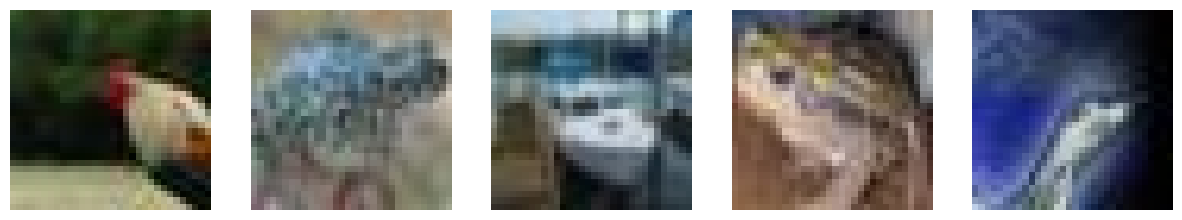

In [ ]:
real_dir = os.path.join(TRAIN_DIR, "REAL")

samples = random.sample(
    os.listdir(real_dir),
    5
)

plt.figure(figsize=(15,5))

for i, img_name in enumerate(samples):

    img = Image.open(
        os.path.join(real_dir, img_name)
    )

    plt.subplot(1,5,i+1)

    plt.imshow(img)

    plt.axis("off")

plt.show()

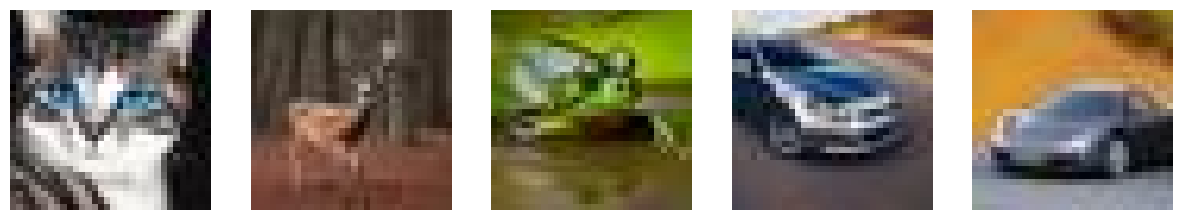

In [ ]:
fake_dir = os.path.join(TRAIN_DIR, "FAKE")

samples = random.sample(
    os.listdir(fake_dir),
    5
)

plt.figure(figsize=(15,5))

for i, img_name in enumerate(samples):

    img = Image.open(
        os.path.join(fake_dir, img_name)
    )

    plt.subplot(1,5,i+1)

    plt.imshow(img)

    plt.axis("off")

plt.show()

# Preprocessing

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# Create Dataset

In [ ]:
train_dataset = ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

test_dataset = ImageFolder(
    TEST_DIR,
    transform=test_transform
)

print(train_dataset.classes)

['FAKE', 'REAL']


In [ ]:
from torch.utils.data import Subset
import random

random.seed(42)

subset_size = 20000

indices = random.sample(
    range(len(train_dataset)),
    subset_size
)

train_dataset_small = Subset(
    train_dataset,
    indices
)

print("Subset Size:", len(train_dataset_small))

Subset Size: 20000


In [ ]:
train_loader = DataLoader(
    train_dataset_small,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Model Creation-EfficientNet-B0 Model

In [ ]:
weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(
    weights=weights
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 143MB/s]


In [ ]:
num_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    num_features,
    2
)

In [ ]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model.to(device)

print(device)

cuda


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [ ]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


# Model Training

In [ ]:
EPOCHS = 1

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1} Loss: {running_loss:.4f}"
    )

100%|██████████| 313/313 [2:01:58<00:00, 23.38s/it]

Epoch 1 Loss: 73.7105


# Model Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)

        outputs = model(images)

        preds = torch.argmax(
            outputs,
            dim=1
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

100%|██████████| 313/313 [2:05:39<00:00, 24.09s/it]


In [ ]:
accuracy = accuracy_score(
    all_labels,
    all_preds
)

print(
    f"Accuracy: {accuracy:.4f}"
)

Accuracy: 0.9518


In [ ]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["FAKE","REAL"]
    )
)

              precision    recall  f1-score   support

        FAKE       0.94      0.96      0.95     10000
        REAL       0.96      0.94      0.95     10000

    accuracy                           0.95     20000
   macro avg       0.95      0.95      0.95     20000
weighted avg       0.95      0.95      0.95     20000



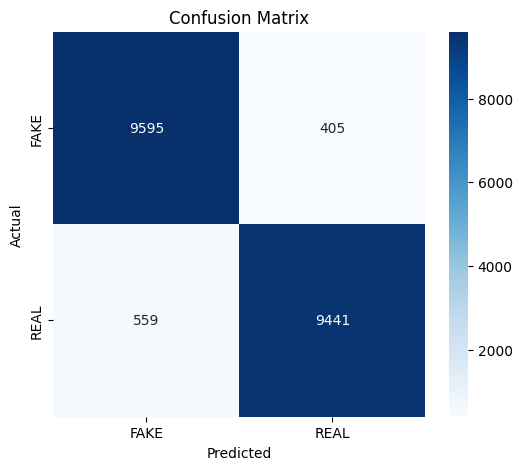

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["FAKE","REAL"],
    yticklabels=["FAKE","REAL"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Saving and Downlaoding

In [ ]:
MODEL_PATH = "image_detector_v1.pth"

torch.save(
    model.state_dict(),
    MODEL_PATH
)

print(f"Model saved at: {MODEL_PATH}")

Model saved at: image_detector_v1.pth


In [ ]:
from google.colab import files

files.download("image_detector_v1.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>